In [36]:
df = pd.read_csv('/kaggle/input/datasets/sumanthvrao/daily-climate-time-series-data/DailyDelhiClimateTest.csv')

In [37]:
df

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333
...,...,...,...,...,...
109,2017-04-20,34.500000,27.500000,5.562500,998.625000
110,2017-04-21,34.250000,39.375000,6.962500,999.875000
111,2017-04-22,32.900000,40.900000,8.890000,1001.600000
112,2017-04-23,32.875000,27.500000,9.962500,1002.125000


In [38]:
df.drop(columns=['humidity','wind_speed','meanpressure'],inplace=True)

In [39]:
df

,date,meantemp
0,2017-01-01,15.913043
1,2017-01-02,18.500000
2,2017-01-03,17.111111
3,2017-01-04,18.700000
4,2017-01-05,18.388889
...,...,...
109,2017-04-20,34.500000
110,2017-04-21,34.250000
111,2017-04-22,32.900000
112,2017-04-23,32.875000


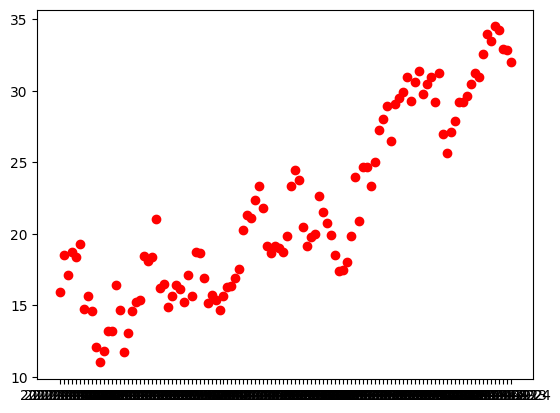

In [40]:
import matplotlib.pyplot as plt
plt.scatter(df['date'],df['meantemp'],color='red')

# Alpha = 1 - Beta
# Beta = 1-Alpha

 # if alpha = 0.9 then beta is 0.1 

# Find the EWMA of the all Data 

In [41]:
x1 = df['meantemp'].ewm(alpha=0.9).mean() # this 

In [42]:
x1

0      15.913043
1      18.264822
2      17.225443
3      18.552677
4      18.405266
         ...    
109    34.403401
110    34.265340
111    33.036534
112    32.891153
113    32.089115
Name: meantemp, Length: 114, dtype: float64

# Changing is to the DataFrame

In [43]:
df['ewma 0.9'] = x1

In [44]:
df

,date,meantemp,ewma 0.9
0,2017-01-01,15.913043,15.913043
1,2017-01-02,18.500000,18.264822
2,2017-01-03,17.111111,17.225443
3,2017-01-04,18.700000,18.552677
4,2017-01-05,18.388889,18.405266
...,...,...,...
109,2017-04-20,34.500000,34.403401
110,2017-04-21,34.250000,34.265340
111,2017-04-22,32.900000,33.036534
112,2017-04-23,32.875000,32.891153


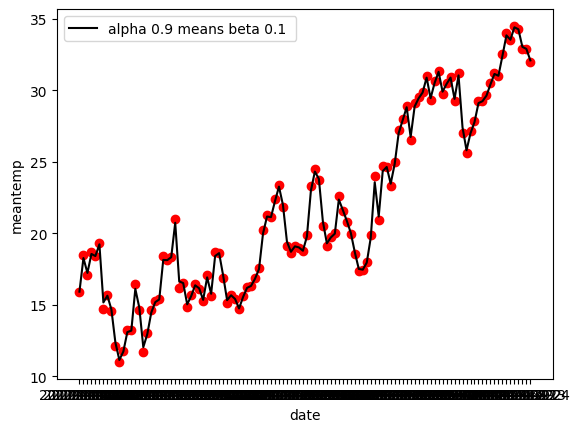

In [58]:
plt.scatter(df['date'],df['meantemp'],color='red')
plt.plot(df['date'],x1,color='black',label='alpha 0.9 means beta 0.1 ')
plt.xlabel('date')
plt.ylabel('meantemp')
plt.legend()

In [46]:
X2 = df['meantemp'].ewm(alpha=0.1).mean()

In [47]:
X2

0      15.913043
1      17.274600
2      17.214272
3      17.646295
4      17.827632
         ...    
109    30.640166
110    31.001152
111    31.191039
112    31.359436
113    31.423493
Name: meantemp, Length: 114, dtype: float64

In [48]:
df['ewma 0.1'] = X2 
df

,date,meantemp,ewma 0.9,ewma 0.1
0,2017-01-01,15.913043,15.913043,15.913043
1,2017-01-02,18.500000,18.264822,17.274600
2,2017-01-03,17.111111,17.225443,17.214272
3,2017-01-04,18.700000,18.552677,17.646295
4,2017-01-05,18.388889,18.405266,17.827632
...,...,...,...,...
109,2017-04-20,34.500000,34.403401,30.640166
110,2017-04-21,34.250000,34.265340,31.001152
111,2017-04-22,32.900000,33.036534,31.191039
112,2017-04-23,32.875000,32.891153,31.359436


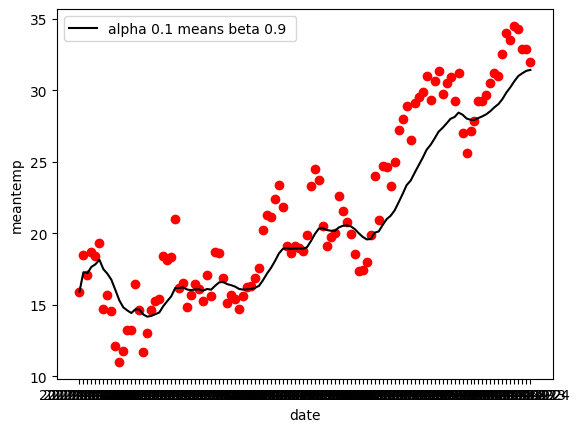

In [59]:
plt.scatter(df['date'],df['meantemp'],color='red')
plt.plot(df['date'],X2,color='black',label='alpha 0.1 means beta 0.9 ')
plt.xlabel('date')
plt.ylabel('meantemp')
plt.legend()